In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
from notebooks.ablations_baselines import *
from notebooks.figures import FONTSIZE

In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("cross-encoder/ms-marco-MiniLM-L12-v2")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 1536


/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
# MiniLM percentage degradations

minilm_degradation = {
    'trec_dl19': (minilm_trec_dl19 - trec_dl19) / minilm_trec_dl19,
    'trec_dl20': (minilm_trec_dl20 - trec_dl20) / minilm_trec_dl20,
    'trec_dl21': (minilm_trec_dl21 - trec_dl21) / minilm_trec_dl21,
    'trec_dl22': (minilm_trec_dl22 - trec_dl22) / minilm_trec_dl22,
    'nfcorpus': (minilm_nfcorpus - nfcorpus) / minilm_nfcorpus,
    'fiqa': (minilm_fiqa - fiqa) / minilm_fiqa,
    'trec_covid': (minilm_trec_covid - trec_covid) / minilm_trec_covid,
    'robust_04': (minilm_robust_04 - robust_04) / minilm_robust_04,
    'nq': (minilm_nq - nq) / minilm_nq,
    'bioasq': (minilm_bioasq - bioasq) / minilm_bioasq,
}

minilm_msmarcos_degradation = {
    'trec_dl19': (minilm_trec_dl19 - trec_dl19) / minilm_trec_dl19,
    'trec_dl20': (minilm_trec_dl20 - trec_dl20) / minilm_trec_dl20,
    'trec_dl21': (minilm_trec_dl21 - trec_dl21) / minilm_trec_dl21,
    'trec_dl22': (minilm_trec_dl22 - trec_dl22) / minilm_trec_dl22,
}

minilm_ood_degradation = {
    'nfcorpus': (minilm_nfcorpus - nfcorpus) / minilm_nfcorpus,
    'fiqa': (minilm_fiqa - fiqa) / minilm_fiqa,
    'trec_covid': (minilm_trec_covid - trec_covid) / minilm_trec_covid,
    'robust_04': (minilm_robust_04 - robust_04) / minilm_robust_04,
    'nq': (minilm_nq - nq) / minilm_nq,
    'bioasq': (minilm_bioasq - bioasq) / minilm_bioasq,
}

print("MiniLM degradation (%):", minilm_degradation)

# Prepare a summary DataFrame for mean and variance of each degradation dictionary
degradation_dicts = {
    'minilm_degradation': minilm_degradation,
    'minilm_msmarcos_degradation': minilm_msmarcos_degradation,
    'minilm_ood_degradation': minilm_ood_degradation,
}

summary = []
for name, d in degradation_dicts.items():
    values = list(d.values())
    summary.append({
        'name': name,
        'mean': 1 - np.mean(values),
        'std': np.std(values)
    })

degradation_stats_df = pd.DataFrame(summary)
print(degradation_stats_df)

MiniLM degradation (%): {'trec_dl19': 0.7037037037037037, 'trec_dl20': 0.782051282051282, 'trec_dl21': 0.6883116883116883, 'trec_dl22': 0.7428571428571429, 'nfcorpus': 0.5306122448979592, 'fiqa': 0.8974358974358975, 'trec_covid': 0.4666666666666666, 'robust_04': 0.6122448979591837, 'nq': 0.8292682926829268, 'bioasq': 0.888888888888889}
                          name      mean       std
0           minilm_degradation  0.285796  0.137444
1  minilm_msmarcos_degradation  0.270769  0.036406
2       minilm_ood_degradation  0.295814  0.174214


In [5]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/6d781ae24e5793032e678476eda44514d8db5191b1a22d3f1e10b198d3704589/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
# Display the first few rows of the DataFrame
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.994487  0.010532
1      1  0.985265  0.011762
2      2  0.954186  0.023893
3      3  0.932036  0.027158
4      4  0.907529  0.030472


In [6]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/ee6d6647915c1655a82d64c879d3a40eb3a6e9b10299bd10e78602e330d2ef45/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']

# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000278  0.000965
1      1  1.000213  0.000515
2      2  0.999416  0.001104
3      3  0.999999  0.000564
4      4  0.999762  0.000595


In [7]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/1b2f76863459cedcc0a623d521ba0ae90e4583597514c38b83eb8919d11484ac/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000382  0.000541
1      1  1.000189  0.000740
2      2  0.999907  0.000476
3      3  0.999841  0.000463
4      4  0.999693  0.000562


In [8]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/bce19006cac85cbee802ecdc663c97bea73a34cd9b3061f7e2b3144f0aac3053/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.994890  0.011052
1      1  0.972406  0.012850
2      2  0.903328  0.035364
3      3  0.874754  0.049425
4      4  0.768028  0.040170


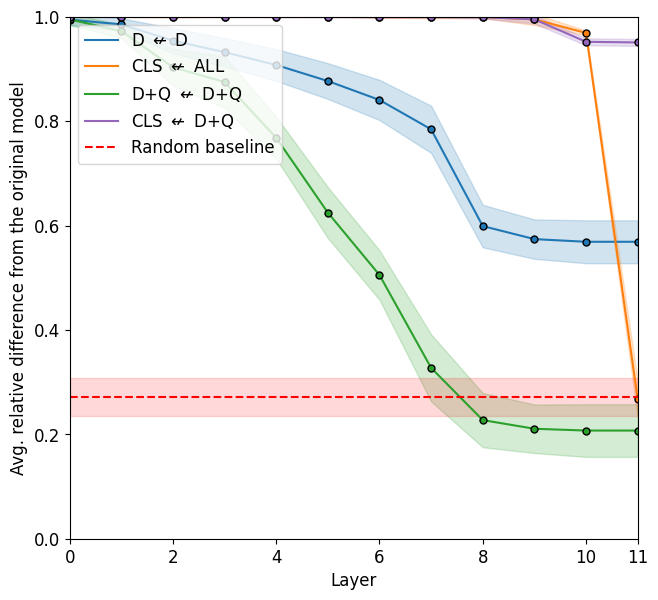

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

# Add horizontal red bar for MiniLM MSMARCOs average and variance
mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_msmarcos_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_msmarcos_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
# plt.savefig("minilm_msmarco_ablations.pdf", format="pdf")
plt.show()


# OOD

In [10]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/aa5604f229fcda7bee429f8627b52f032db05e853a92b3e7204312f096792387/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.992521  0.008580
1      1  0.968548  0.022388
2      2  0.935747  0.035789
3      3  0.911034  0.047792
4      4  0.885636  0.059366


In [11]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/c3d883f1ef3090a1a73fc62f0e70421c713b86bd67ff81fcfbe8d3d468a77a92/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000432  0.001238
1      1  1.000235  0.002016
2      2  1.000580  0.001135
3      3  1.000295  0.001512
4      4  1.000225  0.001584


In [12]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/1653cd009b4cfd87025d740344dc4de5b7f4a9e0e8436e7702a8f3beaa433189/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000298  0.001541
1      1  1.000650  0.001981
2      2  1.000995  0.002403
3      3  1.001147  0.002494
4      4  1.000725  0.001873


In [13]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/f3b40180c975030f5a9942865c649acd9969d6abc4d3c8fa01d655473bd9239b/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv)

    Layer      mean       std
0       0  0.985356  0.012266
1       1  0.922710  0.033310
2       2  0.849927  0.059947
3       3  0.845401  0.065337
4       4  0.713180  0.105613
5       5  0.624270  0.116491
6       6  0.543730  0.124409
7       7  0.325641  0.149769
8       8  0.287418  0.155027
9       9  0.291651  0.154594
10     10  0.288619  0.156552
11     11  0.288619  0.156552


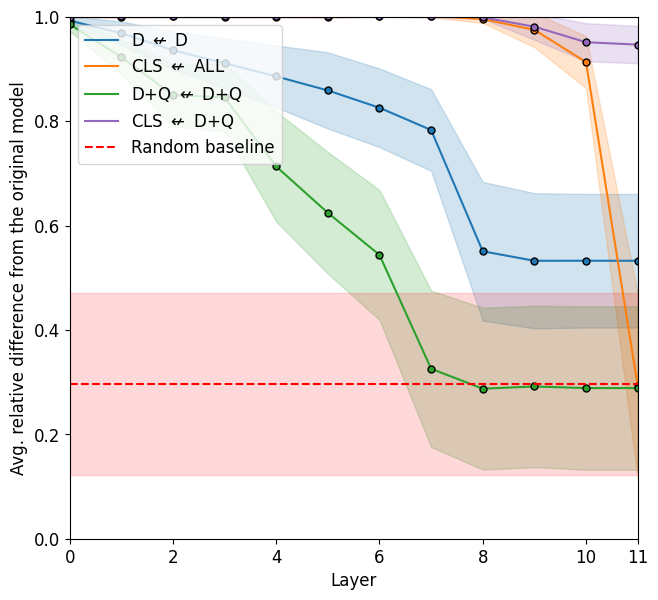

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_ood_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_ood_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
# plt.savefig("minilm_ood_ablations.pdf", format="pdf")
plt.show()


# ALL

In [15]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/d53a15044b90c6324456e5bbcc7a53bf1b306a8e6fb26ba6404f5e53d7b33034/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.993307  0.009459
1      1  0.975235  0.020571
2      2  0.943123  0.032840
3      3  0.919435  0.042087
4      4  0.894393  0.051000


In [16]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/62ee05dcf5b753d6b794032165ec3b2f8cfd15a16c2ae83bc4d7b2f448c38290/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000370  0.001139
1      1  1.000226  0.001595
2      2  1.000114  0.001259
3      3  1.000176  0.001233
4      4  1.000040  0.001303


In [17]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/dce57cc8600c9989ae2b4e1823f666bcd26b613a25cb202fc8f722b924c2befa/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000332  0.001242
1      1  1.000466  0.001620
2      2  1.000560  0.001959
3      3  1.000624  0.002056
4      4  1.000312  0.001577


In [18]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/62bdb25c0f89a4c126eb97367eef1499004cb77b1878383280eef8f62d85e508/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv)

    Layer      mean       std
0       0  0.989170  0.012686
1       1  0.942589  0.036394
2       2  0.871287  0.057800
3       3  0.857142  0.061199
4       4  0.735119  0.089777
5       5  0.624463  0.095359
6       6  0.528344  0.102640
7       7  0.326301  0.122931
8       8  0.263351  0.127937
9       9  0.259258  0.129537
10     10  0.256054  0.131582
11     11  0.256054  0.131582


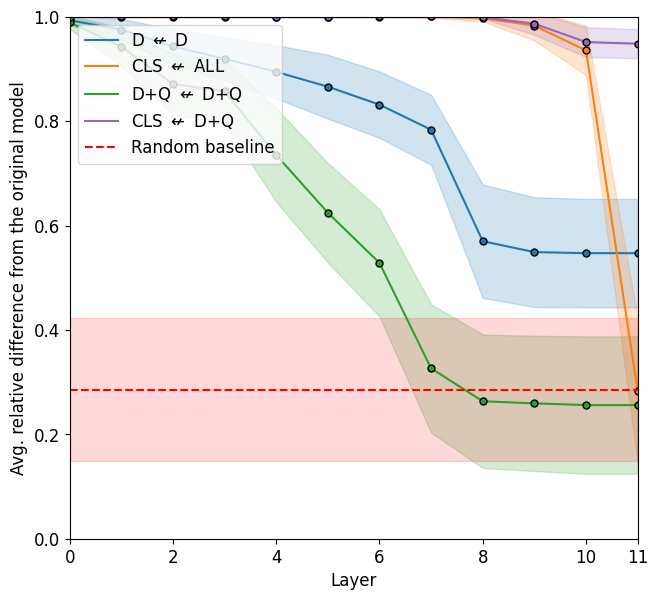

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')
plt.legend(loc='upper left')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
# plt.savefig("minilm_all_ablations.pdf", format="pdf")
plt.show()


In [20]:
# Query+SEP1+Doc-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/fb799c4e9f9d474674a0e6e98a2a968c6851dfdf56f4df261f725dd406b282bc/storage/summary_results.csv'
query_sep_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_sep_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_sep_doc_to_cls_csv = query_sep_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_sep_doc_to_cls_csv['Layer'] = range(len(query_sep_doc_to_cls_csv))
query_sep_doc_to_cls_csv['mean'] = 1 - query_sep_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_sep_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000388  0.001237
1      1  1.000467  0.001461
2      2  1.000565  0.002148
3      3  1.000236  0.001761
4      4  1.000177  0.001650


In [21]:
# Query+SEP1+Doc+SEP2-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/9f399a5de93a57e44384f7619adaf3c4a1ab32ead2ec2841652c20c8b0d2fbf4/storage/summary_results.csv'
query_both_sep_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_both_sep_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_both_sep_doc_to_cls_csv = query_both_sep_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_both_sep_doc_to_cls_csv['Layer'] = range(len(query_both_sep_doc_to_cls_csv))
query_both_sep_doc_to_cls_csv['mean'] = 1 - query_both_sep_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_both_sep_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000730  0.000793
1      1  1.000384  0.001413
2      2  1.000439  0.001423
3      3  1.000268  0.001553
4      4  1.000350  0.001657


In [22]:
# Query+SEP1+Doc+SEP2-->Query+SEP1+Doc+SEP2 ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/32af7233c54539991446bd9cd014f569dad3cb530d896c749631fd6d29807c24/storage/summary_results.csv'
query_both_sep_doc_to_query_both_sep_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_both_sep_doc_to_query_both_sep_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_both_sep_doc_to_query_both_sep_doc_csv = query_both_sep_doc_to_query_both_sep_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_both_sep_doc_to_query_both_sep_doc_csv['Layer'] = range(len(query_both_sep_doc_to_query_both_sep_doc_csv))
query_both_sep_doc_to_query_both_sep_doc_csv['mean'] = 1 - query_both_sep_doc_to_query_both_sep_doc_csv['mean']
# Display the first few rows of the DataFrame
print(query_both_sep_doc_to_query_both_sep_doc_csv.head())

   Layer      mean       std
0      0  0.989337  0.012992
1      1  0.938652  0.037427
2      2  0.857095  0.058125
3      3  0.818062  0.068886
4      4  0.663399  0.081479


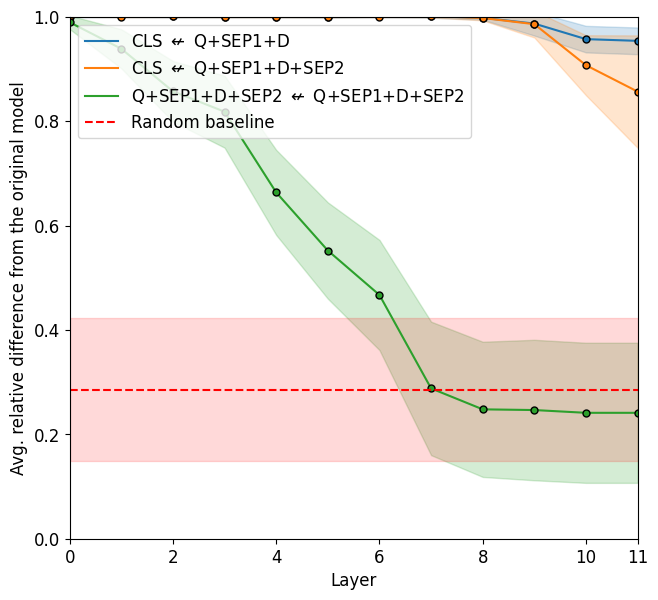

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'CLS $\nleftarrow$ Q+SEP1+D',
        'df': query_sep_doc_to_cls_csv,
        'highlight': query_sep_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ Q+SEP1+D+SEP2',
        'df': query_both_sep_doc_to_cls_csv,
        'highlight': query_both_sep_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'Q+SEP1+D+SEP2 $\nleftarrow$ Q+SEP1+D+SEP2',
        'df': query_both_sep_doc_to_query_both_sep_doc_csv,
        'highlight': query_both_sep_doc_to_query_both_sep_doc_csv['Layer'].tolist(),
        'color': palette[2]
    },
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')
plt.legend(loc='upper left')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'minilm_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
# plt.savefig("minilm_all_additional_ablations.pdf", format="pdf")
plt.show()
